In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.animation as animation # for movie
import jax
Array = jax.Array
import jax.numpy as jnp

#import interpax
#import optax

from vp_solver.jax_mirror_solver import make_mesh, VlasovPoissonSolver
#from vp_solver.utils import external_electric_field
#from vp_solver.utils import make_cost_function_kl, make_cost_function_ee, make_cost_function_eet
#from vp_solver.utils import plot_inital_solve, plot_results_TS

#jax.config.update("jax_enable_x64", True)

In [2]:
# Setup for the forward solver
nz = 128
#ny = 128
nv = 128
nmu = 128
dt = 0.1
t_final = 50.0
t_values = jnp.linspace(0, t_final, int(t_final / dt)+1)
#print(t_values)
LZ = 2*jnp.pi
LV = 4.0
#LMU = 6.0 We will chose it later

## B parameters
I1 = 1.0
I2 = 1.0
R1 = 1.0
R2 = 1.0

zeta = jnp.array([0.1,1.0,3.0])

z_c1 = -LZ + zeta
z_c2 = LZ - zeta

#print(z_c1)
#print(z_c2)
#z_c1 = -LZ + 1.0
#z_c2 = LZ - 1.0

#z_c3 = -1.0
#z_c4 = 1.0

In [3]:
def build_B(I, R, z_c):
    def B(z):
        return (I * R**2) / ((z - z_c)**2 + R**2)**(3/2)
    return B



def build_partial_B(I, R, z_c):
    def partial_B(z):
        return - (3 * I * R**2 * (z - z_c)) / ((z - z_c)**2 + R**2)**(5/2)
    return partial_B

In [4]:
### We define mu_max
zs = jnp.linspace(-LZ, LZ, nz, endpoint=True)

B_norm_1 = build_B(I1, R1, z_c1[0])
B_norm_2 = build_B(I2, R2, z_c2[0])


B0 = B_norm_1(zs) + B_norm_2(zs)

bound_l0 = jnp.argwhere(B_norm_1(zs) == jnp.max(B_norm_1(zs)), size=1)[0,0]
bound_u0 = jnp.argwhere(B_norm_2(zs) == jnp.max(B_norm_2(zs)), size=1)[0,0]

B_max = jnp.max(B0)
B_min = jnp.min(B0)
mu_max0 = -jnp.log(1e-12)/(B_max)
mu_min0 = 1.0/(2*B_min*(B_max/B_min - 1))
#mu_max0 = LV**2 / (2*(B_max - B_min))
print("zeta: {:.1f}".format(zeta[0]))
print("B_min: {:.7f}".format(B_min))
print("B_max: {:.7f}".format(B_max))
print("Mirror ratio (B_max/B_min): {:.7f}".format(B_max/B_min))
print("mu_0: {:.7f}".format(mu_max0))
print("(z_1,z_2): ({:.1f},{:.1f})".format(bound_l0,bound_u0))

B_norm_1 = build_B(I1, R1, z_c1[1])
B_norm_2 = build_B(I2, R2, z_c2[1])

B1 = B_norm_1(zs) + B_norm_2(zs)

bound_l1 = jnp.argwhere(B_norm_1(zs) == jnp.max(B_norm_1(zs)), size=1)[0,0]
bound_u1 = jnp.argwhere(B_norm_2(zs) == jnp.max(B_norm_2(zs)), size=1)[0,0]

B_max = jnp.max(B1)
B_min = jnp.min(B1)
mu_max1 = -jnp.log(1e-12)/(B_max)
mu_min1 = 1.0/(2*B_min*(B_max/B_min - 1)) 
#mu_max1 = LV**2 / (2*(B_max - B_min))
print("zeta: {:.1f}".format(zeta[1]))
print("B_min: {:.7f}".format(B_min))
print("B_max: {:.7f}".format(B_max))
print("Mirror ratio (B_max/B_min): {:.7f}".format(B_max/B_min))
print("mu_0: {:.7f}".format(mu_max1))
print("(z_1,z_2): ({:.1f},{:.1f})".format(bound_l1,bound_u1))

B_norm_1 = build_B(I1, R1, z_c1[2])
B_norm_2 = build_B(I2, R2, z_c2[2])

B2 = B_norm_1(zs) + B_norm_2(zs)

bound_l2 = jnp.argwhere(B_norm_1(zs) == jnp.max(B_norm_1(zs)), size=1)[0,0]
bound_u2 = jnp.argwhere(B_norm_2(zs) == jnp.max(B_norm_2(zs)), size=1)[0,0]

B_max = jnp.max(B2)
B_min = jnp.min(B2)
mu_max2 = -jnp.log(1e-12)/(B_max)
mu_min2 = 1.0/(2*B_min*(B_max/B_min - 1)) ## minimum value for trapping
#mu_max2 = LV**2 / (2*(B_max - B_min))
print("zeta: {:.1f}".format(zeta[2]))
print("B_min: {:.7f}".format(B_min))
print("B_max: {:.7f}".format(B_max))
print("Mirror ratio (B_max/B_min): {:.7f}".format(B_max/B_min))
print("mu_0: {:.7f}".format(mu_max2))
print("(z_1,z_2): ({:.1f},{:.1f})".format(bound_l2,bound_u2))

zeta: 0.1
B_min: 0.0081420
B_max: 1.0005218
Mirror ratio (B_max/B_min): 122.8842621
mu_0: 27.6166115
(z_1,z_2): (1.0,126.0)
zeta: 1.0
B_min: 0.0128713
B_max: 1.0006677
Mirror ratio (B_max/B_min): 77.7440414
mu_0: 27.6125832
(z_1,z_2): (10.0,117.0)
zeta: 3.0
B_min: 0.0327466
B_max: 1.0018723
Mirror ratio (B_max/B_min): 30.5947399
mu_0: 27.5793858
(z_1,z_2): (30.0,97.0)


In [5]:
LMU = max(mu_max0, mu_max1, mu_max2)
#LMU = 150.0
mesh = make_mesh(LZ, LV, LMU, nz, nv, nmu)


### zeta=0.1


B_norm_1 = build_B(I1, R1, z_c1[0])
partial_B1_norm = build_partial_B(I1, R1, z_c1[0])
B_norm_2 = build_B(I2, R2, z_c2[0])
partial_B2_norm = build_partial_B(I2, R2, z_c2[0])

B_norm = B_norm_1(mesh.Z) + B_norm_2(mesh.Z)

B0 = B_norm_1(mesh.zs) + B_norm_2(mesh.zs)
partial_B0 = partial_B1_norm(mesh.zs) + partial_B2_norm(mesh.zs)
g0 = partial_B0 / B0

f_eq0 = jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) #/ B_norm

sigma_z = 1.0
f_eq_Z = 0.1 + jnp.exp(-mesh.Z**2/(2*sigma_z**2))

f_iv0 = f_eq_Z * f_eq0

C = 1 / (jnp.sum((jnp.sum(f_iv0, axis=(1,2))*mesh.dv*mesh.dmu)[bound_l0:bound_u0+1])*mesh.dz)

f_iv0 = C * f_iv0

### zeta=2.5


B_norm_1 = build_B(I1, R1, z_c1[1])
partial_B1_norm = build_partial_B(I1, R1, z_c1[1])
B_norm_2 = build_B(I2, R2, z_c2[1])
partial_B2_norm = build_partial_B(I2, R2, z_c2[1])

B_norm = B_norm_1(mesh.Z) + B_norm_2(mesh.Z)

B1 = B_norm_1(mesh.zs) + B_norm_2(mesh.zs)
partial_B1 = partial_B1_norm(mesh.zs) + partial_B2_norm(mesh.zs)
g1 = partial_B1 / B1

f_eq1 = jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) #/ B_norm

sigma_z = 1.0
f_eq_Z = 0.1 + jnp.exp(-mesh.Z**2/(2*sigma_z**2))

f_iv1 = f_eq_Z * f_eq1

C = 1 / (jnp.sum((jnp.sum(f_iv1, axis=(1,2))*mesh.dv*mesh.dmu)[bound_l1:bound_u1+1])*mesh.dz)

f_iv1 = C * f_iv1

### zeta=5.0


B_norm_1 = build_B(I1, R1, z_c1[2])
partial_B1_norm = build_partial_B(I1, R1, z_c1[2])
B_norm_2 = build_B(I2, R2, z_c2[2])
partial_B2_norm = build_partial_B(I2, R2, z_c2[2])

B_norm = B_norm_1(mesh.Z) + B_norm_2(mesh.Z)

B2 = B_norm_1(mesh.zs) + B_norm_2(mesh.zs)
partial_B2 = partial_B1_norm(mesh.zs) + partial_B2_norm(mesh.zs)
g2 = partial_B2 / B2


f_eq2 = jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) #/ B_norm

sigma_z = 1.0
f_eq_Z = 0.1 + jnp.exp(-mesh.Z**2/(2*sigma_z**2))

f_iv2 = f_eq_Z * f_eq2

C = 1 / (jnp.sum((jnp.sum(f_iv2, axis=(1,2))*mesh.dv*mesh.dmu)[bound_l2:bound_u2+1])*mesh.dz)

f_iv2 = C * f_iv2

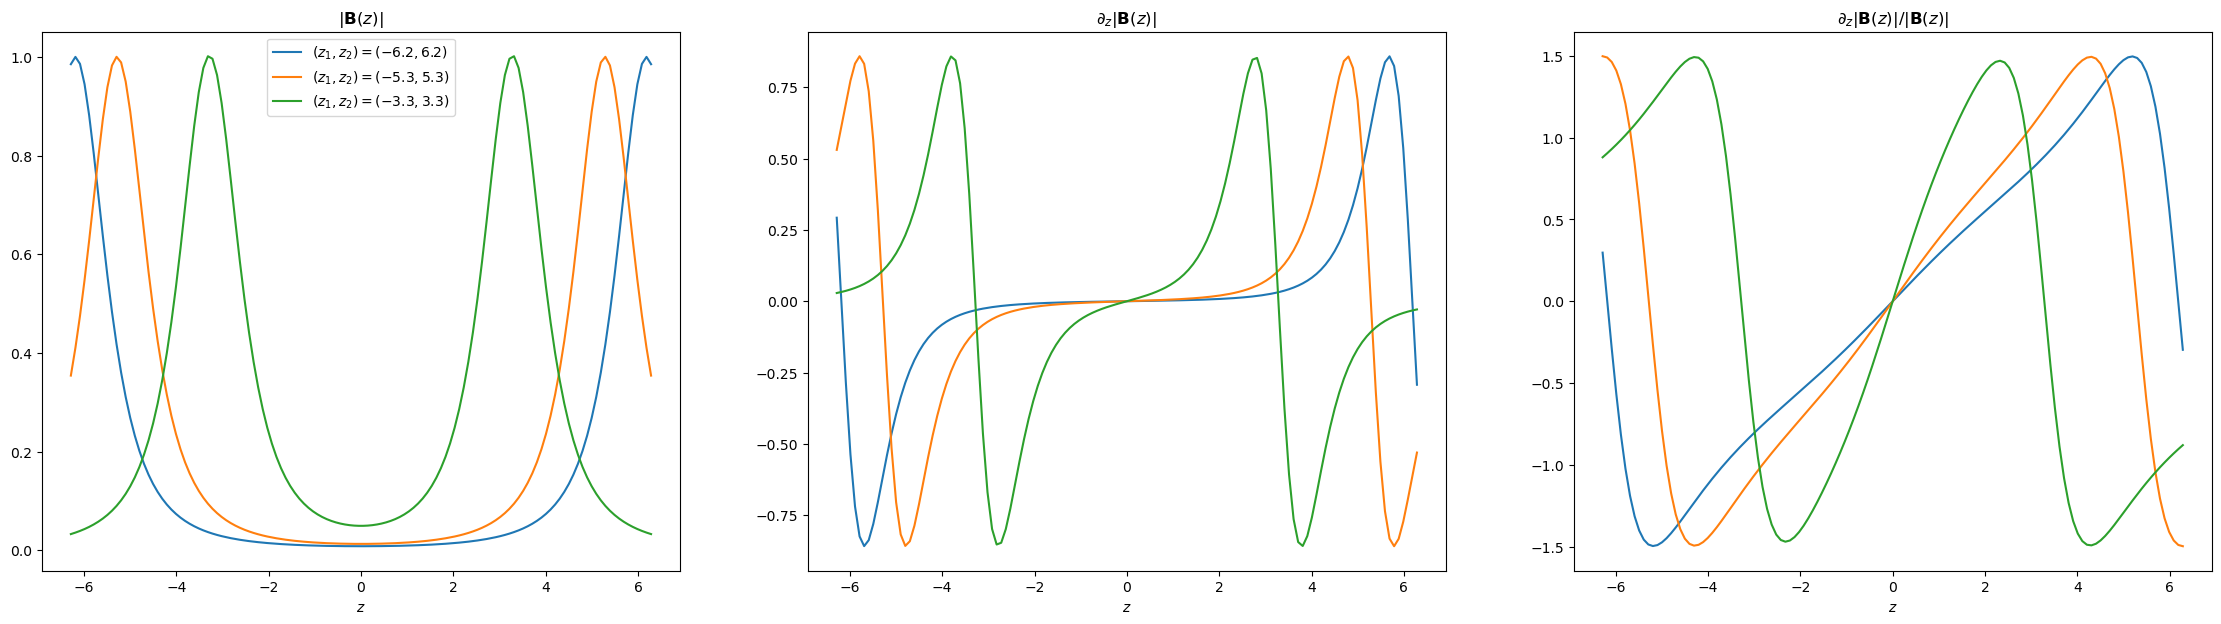

In [9]:
fig, axs = plt.subplots(1,3, figsize=(28,7))

axs[0].plot(mesh.zs, B0, label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[0],z_c2[0]))
axs[0].plot(mesh.zs, B1, label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[1],z_c2[1]))
axs[0].plot(mesh.zs, B2, label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[2],z_c2[2]))
axs[0].set_xlabel('$z$')
axs[0].set_title('$|\\mathbf{B}(z)|$')
axs[0].legend()

axs[1].plot(mesh.zs, partial_B0, label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[0],z_c2[0]))
axs[1].plot(mesh.zs, partial_B1, label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[1],z_c2[1]))
axs[1].plot(mesh.zs, partial_B2, label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[2],z_c2[2]))
axs[1].set_xlabel('$z$')
axs[1].set_title('$\\partial_{z}|\\mathbf{B}(z)|$')
#axs[1].legend()

axs[2].plot(mesh.zs, g0, label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[0],z_c2[0]))
axs[2].plot(mesh.zs, g1, label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[1],z_c2[1]))
axs[2].plot(mesh.zs, g2, label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[2],z_c2[2]))
axs[2].set_xlabel('$z$')
axs[2].set_title('$\\partial_{z}|\\mathbf{B}(z)|/|\\mathbf{B}(z)|$')
#axs[2].legend()

plt.show()
#plt.savefig('Mirror/Plots/two_coils/magnetic_fields.png', dpi=300, transparent=True, bbox_inches="tight")

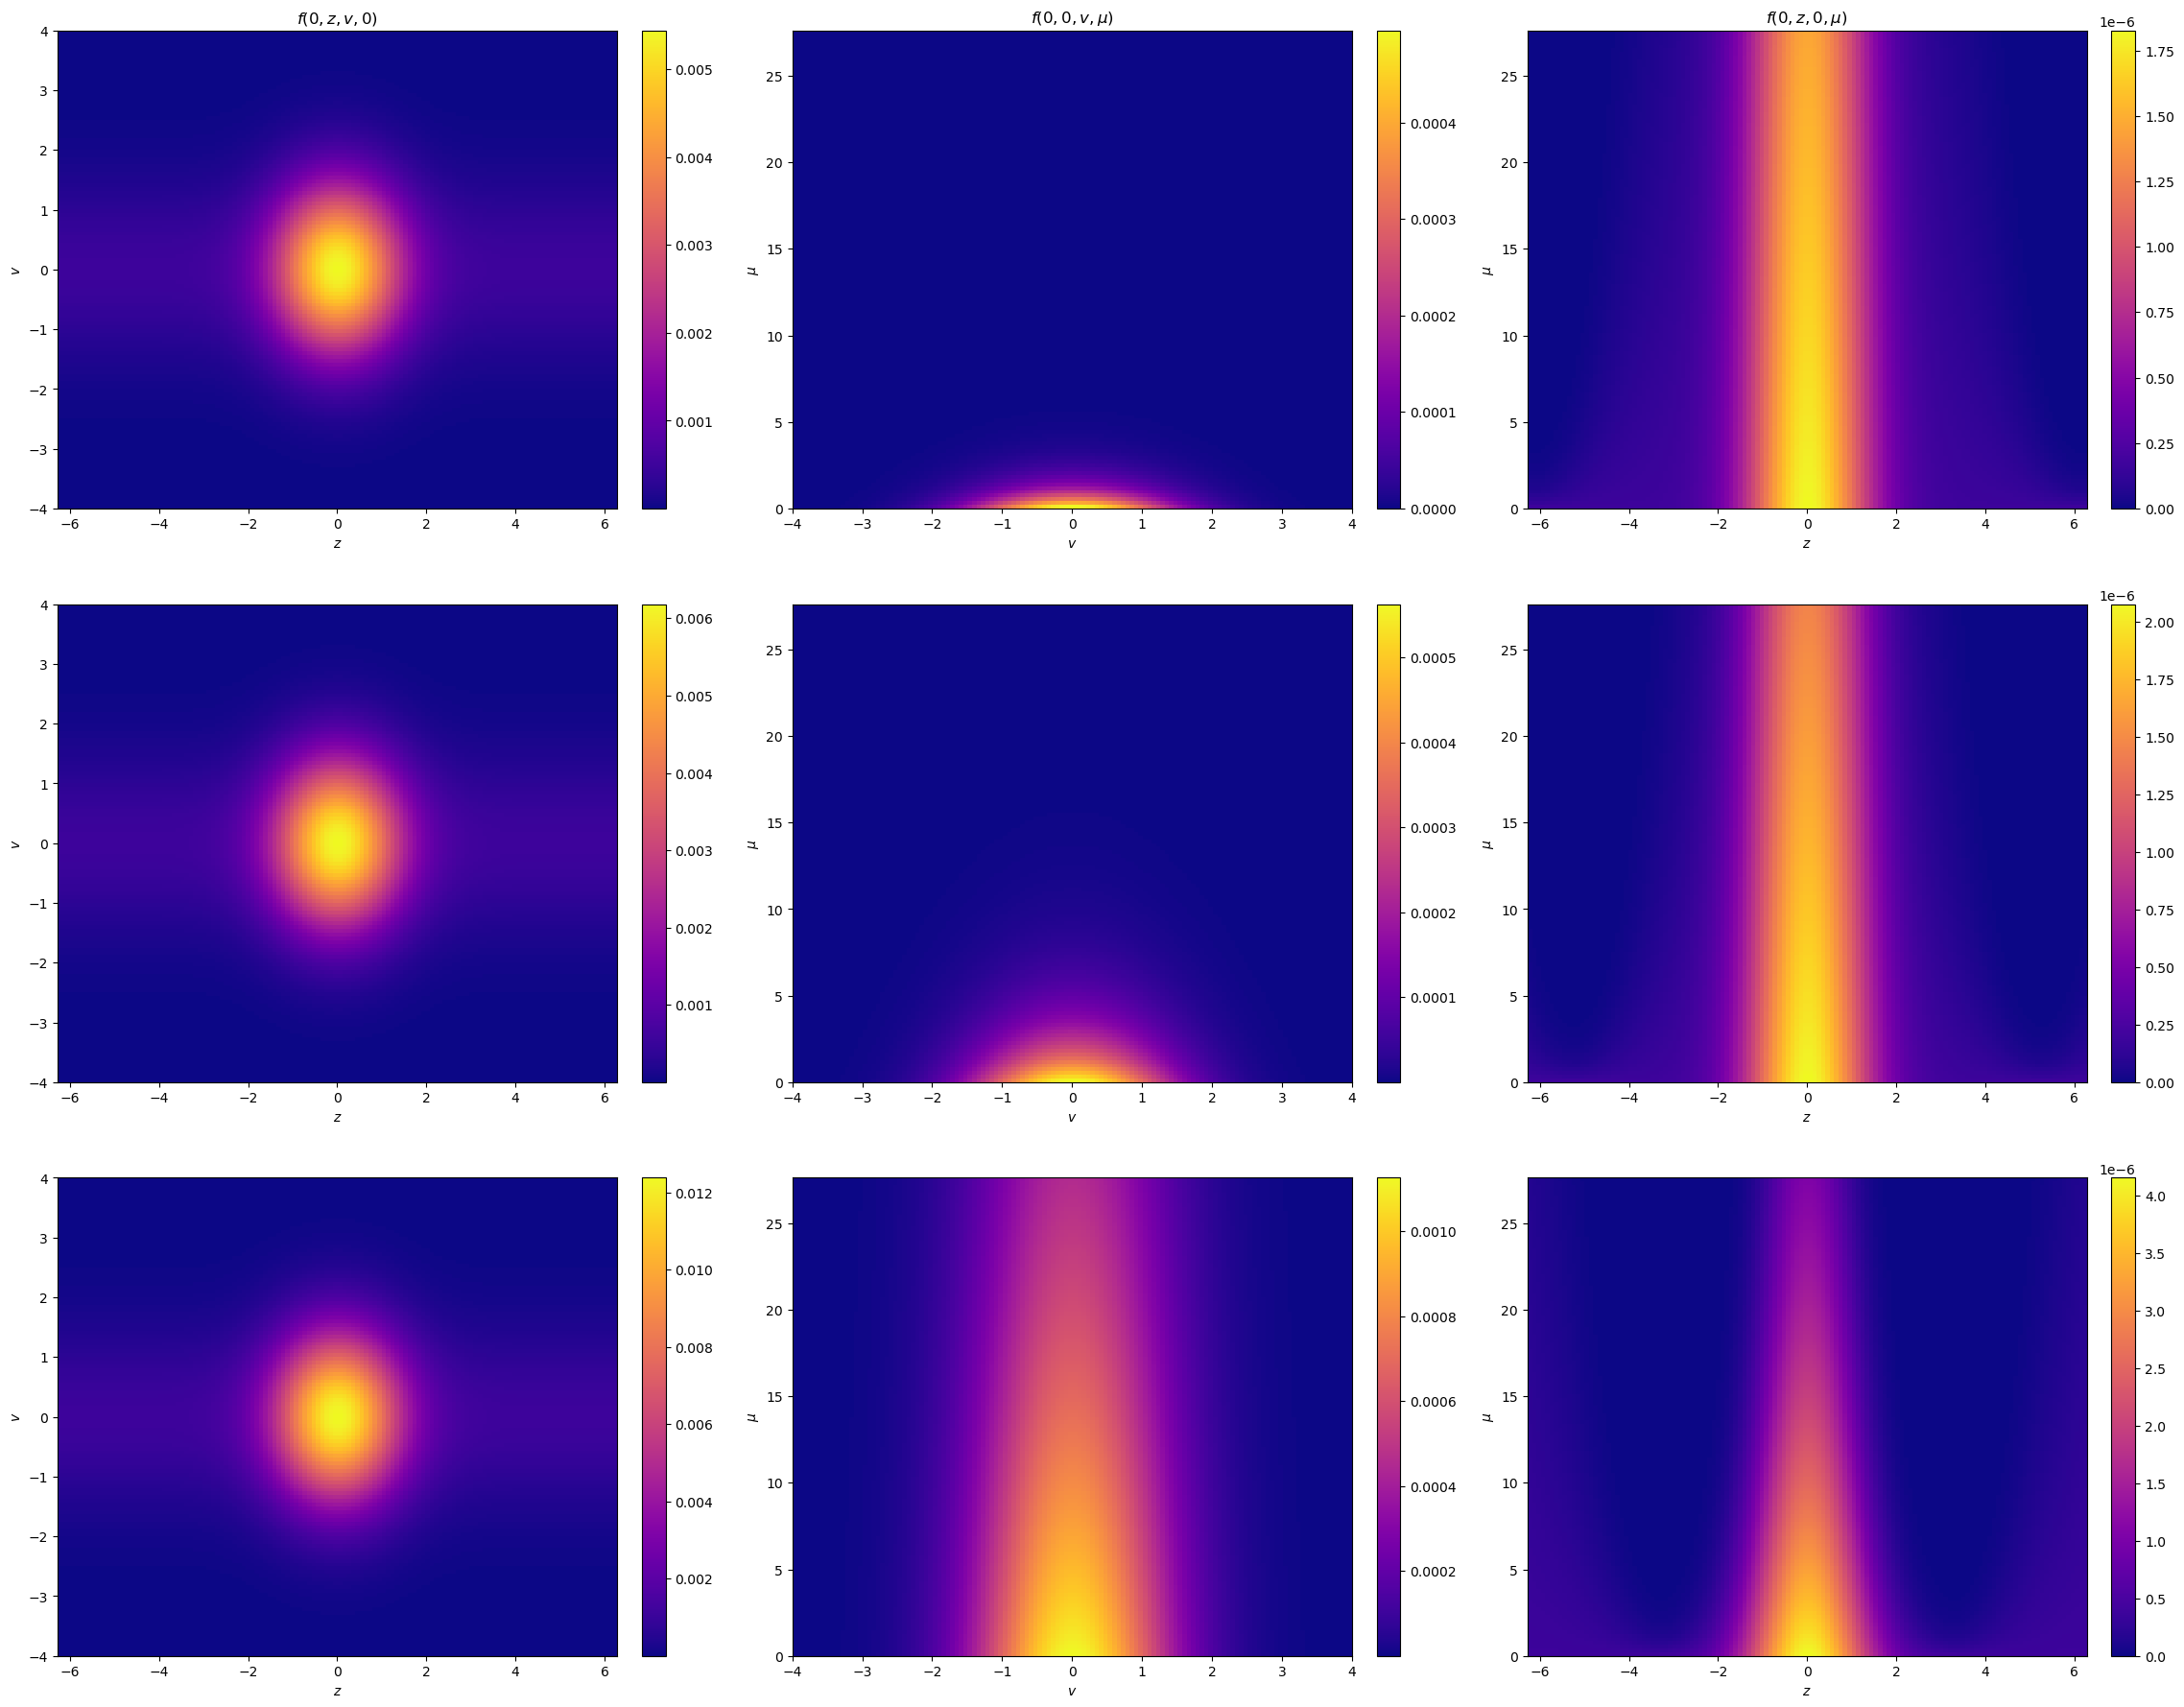

In [16]:
fig, axs = plt.subplots(3,3 ,figsize=(28, 22))

im = axs[0,0].imshow(f_iv0[:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[0,0].set_xlabel("$z$")
axs[0,0].set_ylabel("$v$")
axs[0,0].set_title("$f(0,z,v,0)$")
fig.colorbar(im, ax=axs[0,0], fraction=0.046, pad=0.04)

im = axs[0,1].imshow(f_iv0[0,:,:].T, origin="lower", extent=[mesh.vs[0], mesh.vs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma')
axs[0,1].set_xlabel("$v$")
axs[0,1].set_ylabel("$\\mu$")
axs[0,1].set_title("$f(0,0,v,\\mu)$")
fig.colorbar(im, ax=axs[0,1], fraction=0.046, pad=0.04)

im = axs[0,2].imshow(f_iv0[:,0,:].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma')
axs[0,2].set_xlabel("$z$")
axs[0,2].set_ylabel("$\\mu$")
axs[0,2].set_title("$f(0,z,0,\\mu)$")
fig.colorbar(im, ax=axs[0,2], fraction=0.046, pad=0.04)


im = axs[1,0].imshow(f_iv1[:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[1,0].set_xlabel("$z$")
axs[1,0].set_ylabel("$v$")
#axs[1,0].set_title("$f(0,z,v,0)$")
fig.colorbar(im, ax=axs[1,0], fraction=0.046, pad=0.04)

im = axs[1,1].imshow(f_iv1[0,:,:].T, origin="lower", extent=[mesh.vs[0], mesh.vs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma')
axs[1,1].set_xlabel("$v$")
axs[1,1].set_ylabel("$\\mu$")
#axs[1,1].set_title("$f(0,0,v,\\mu)$")
fig.colorbar(im, ax=axs[1,1], fraction=0.046, pad=0.04)

im = axs[1,2].imshow(f_iv1[:,0,:].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma')
axs[1,2].set_xlabel("$z$")
axs[1,2].set_ylabel("$\\mu$")
#axs[1,2].set_title("$f(0,z,0,\\mu)$")
fig.colorbar(im, ax=axs[1,2], fraction=0.046, pad=0.04)


im = axs[2,0].imshow(f_iv2[:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[2,0].set_xlabel("$z$")
axs[2,0].set_ylabel("$v$")
#axs[2,0].set_title("$f(0,z,v,0)$")
fig.colorbar(im, ax=axs[2,0], fraction=0.046, pad=0.04)

im = axs[2,1].imshow(f_iv2[0,:,:].T, origin="lower", extent=[mesh.vs[0], mesh.vs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma')
axs[2,1].set_xlabel("$v$")
axs[2,1].set_ylabel("$\\mu$")
#axs[2,1].set_title("$f(0,0,v,\\mu)$")
fig.colorbar(im, ax=axs[2,1], fraction=0.046, pad=0.04)

im = axs[2,2].imshow(f_iv2[:,0,:].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma')
axs[2,2].set_xlabel("$z$")
axs[2,2].set_ylabel("$\\mu$")
#axs[2,2].set_title("$f(0,z,0,\\mu)$")
fig.colorbar(im, ax=axs[2,2], fraction=0.046, pad=0.04)


plt.show()
#plt.savefig('Mirror/Plots/two_coils/initial_density.png', dpi=300, transparent=True, bbox_inches="tight")

In [17]:
solver = VlasovPoissonSolver(mesh=mesh, dt=dt)
#solver_0 = VlasovPoissonSolver(mesh=mesh0, dt=dt)
#solver_1 = VlasovPoissonSolver(mesh=mesh1, dt=dt)
#solver_2 = VlasovPoissonSolver(mesh=mesh2, dt=dt)

# JIT-compiled forward solver
solver_jit = jax.jit(solver.run_forward_jax_scan, static_argnames=('t_final',))

In [18]:
f_array_0, f_total_0, E_array_0, ee_array_0, rho_array_0 = solver_jit(f_iv0, B0, partial_B0, g0, t_final=t_final)
rho_array_0 = jnp.vstack([jnp.sum(f_iv0, axis=(1,2))*mesh.dv*mesh.dmu, rho_array_0])
f_array_1, f_total_1, E_array_1, ee_array_1, rho_array_1 = solver_jit(f_iv1, B1, partial_B1, g1, t_final=t_final)
rho_array_1 = jnp.vstack([jnp.sum(f_iv1, axis=(1,2))*mesh.dv*mesh.dmu, rho_array_1])
f_array_2, f_total_2, E_array_2, ee_array_2, rho_array_2 = solver_jit(f_iv2, B2, partial_B2, g2, t_final=t_final)
rho_array_2 = jnp.vstack([jnp.sum(f_iv2, axis=(1,2))*mesh.dv*mesh.dmu, rho_array_2])

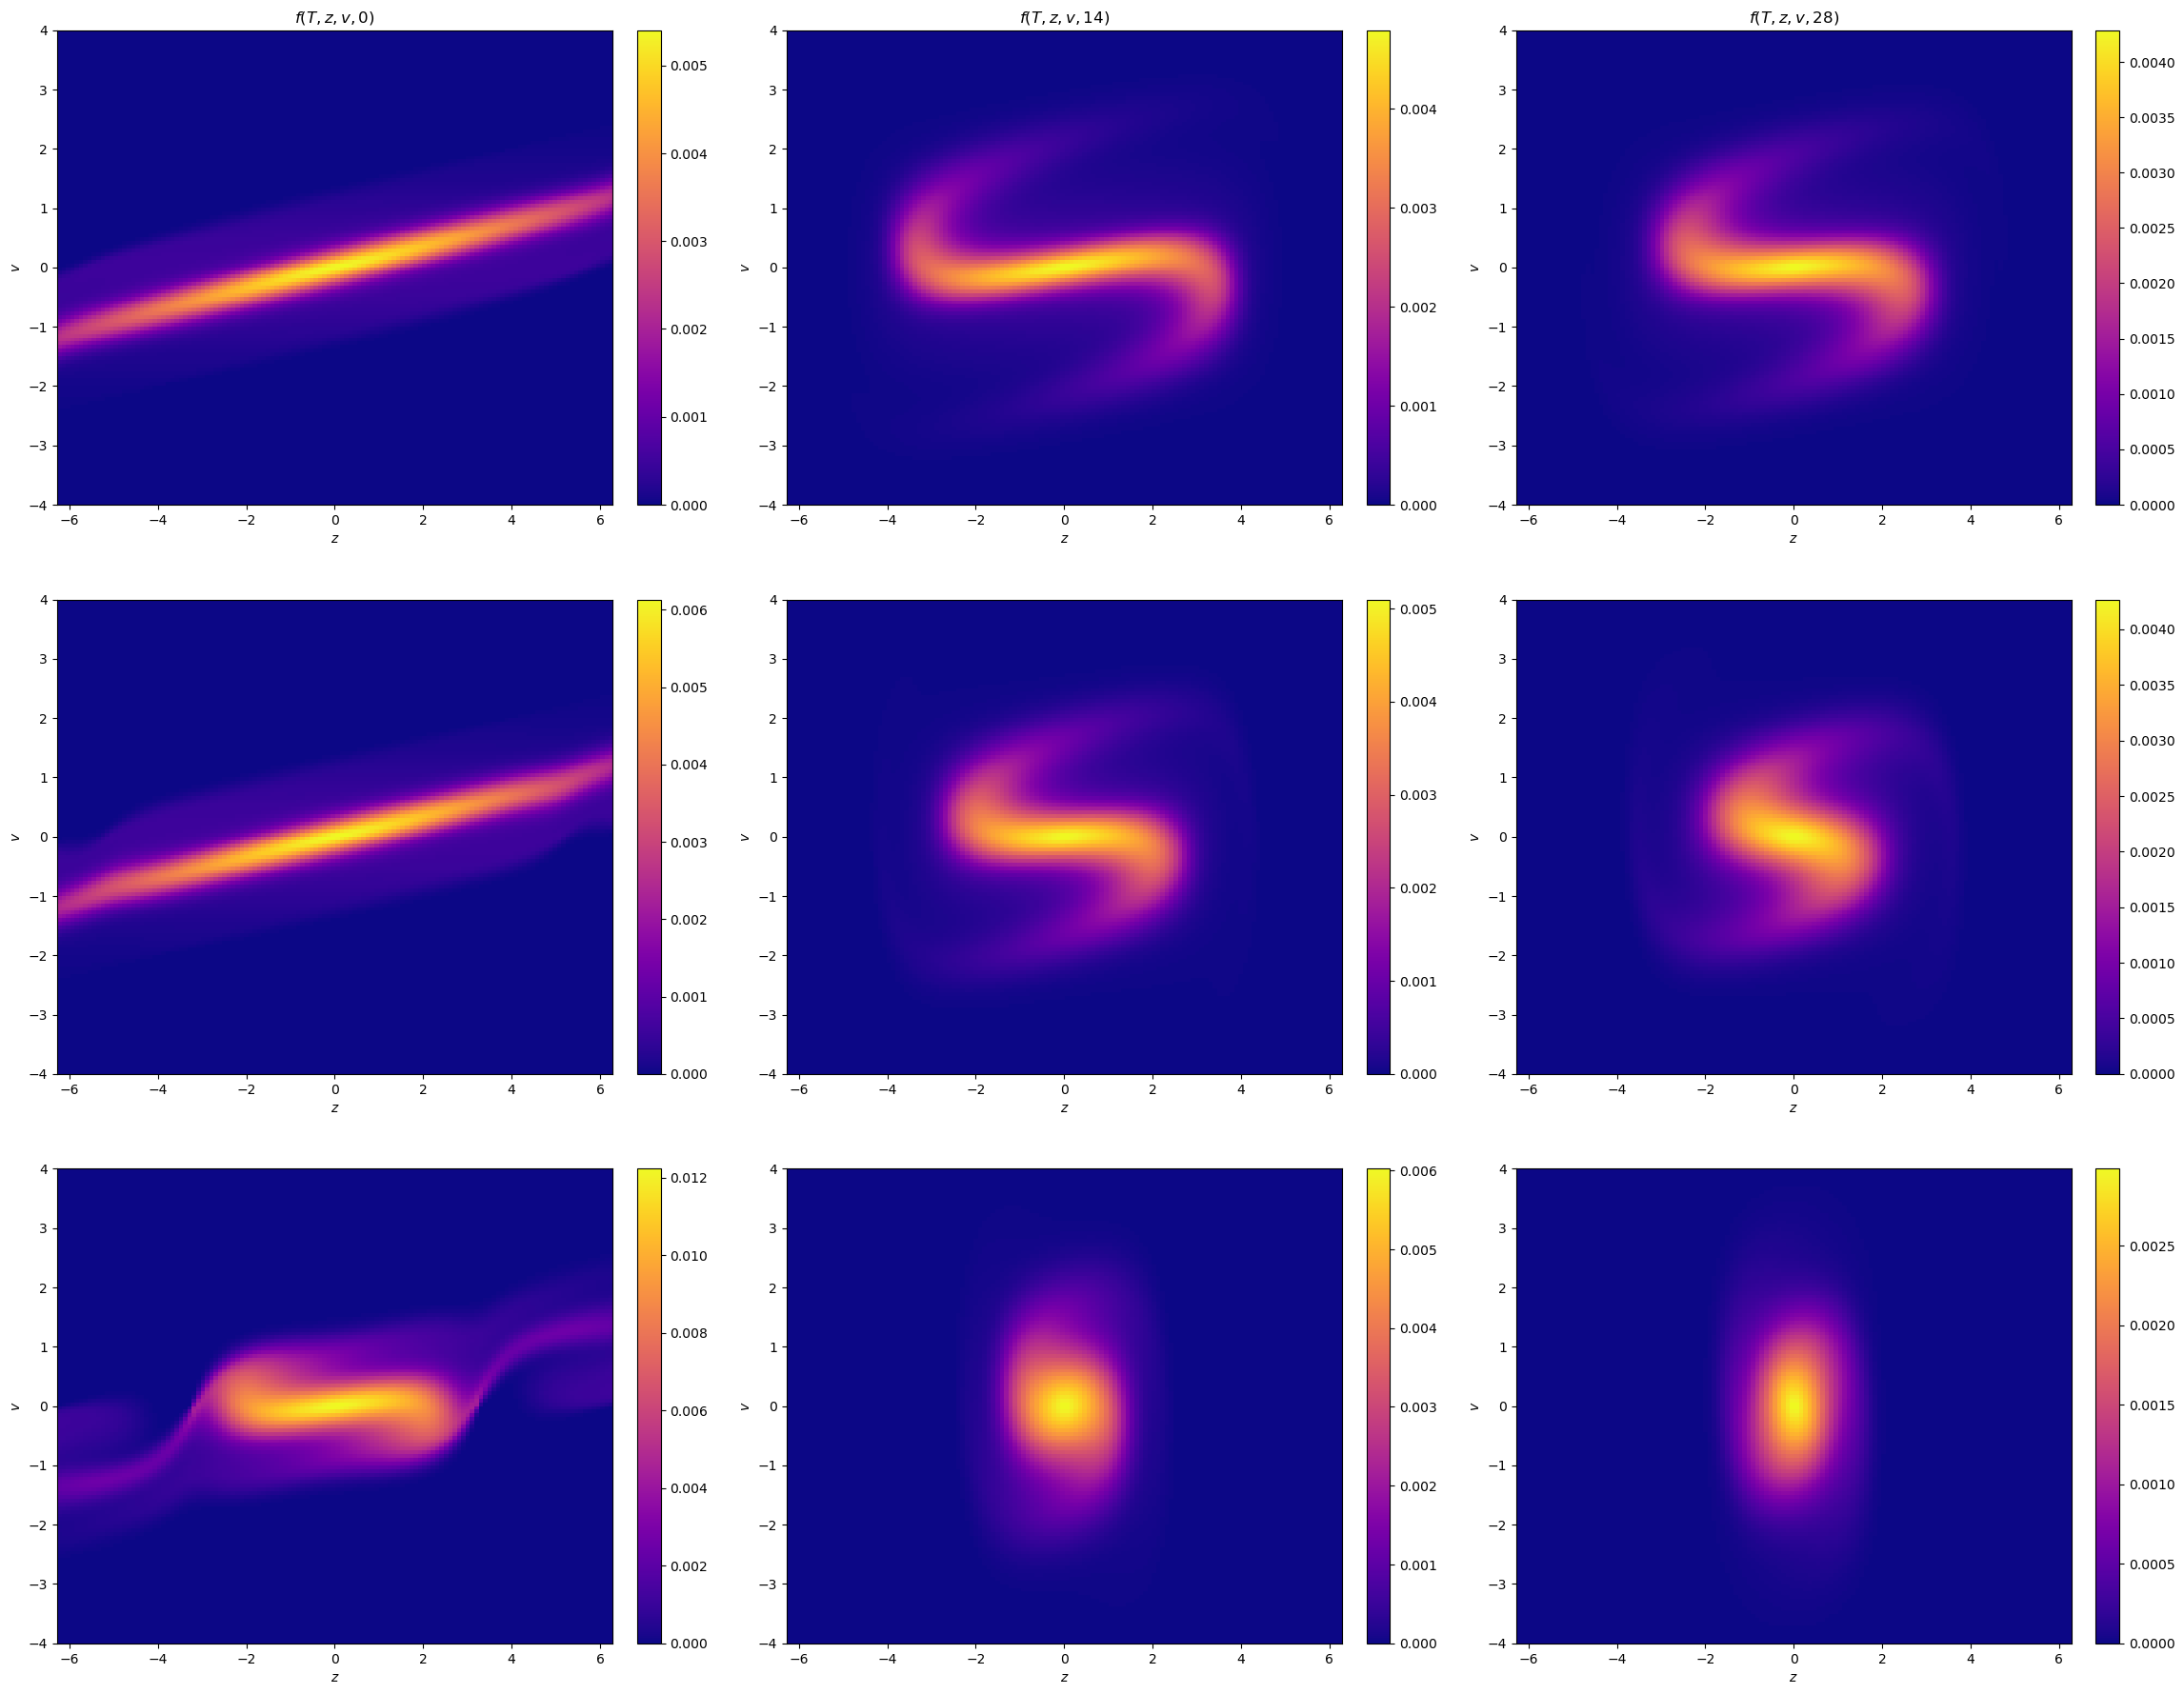

In [21]:
fig, axs = plt.subplots(3,3 ,figsize=(28, 22))

im = axs[0,0].imshow(f_total_0[50,:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[0,0].set_xlabel("$z$")
axs[0,0].set_ylabel("$v$")
axs[0,0].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[0]))
fig.colorbar(im, ax=axs[0,0], fraction=0.046, pad=0.04)

im = axs[0,1].imshow(f_total_0[50,:,:,int(mesh.nmu/2)].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[0,1].set_xlabel("$z$")
axs[0,1].set_ylabel("$v$")
axs[0,1].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[int(mesh.nmu/2)]))
fig.colorbar(im, ax=axs[0,1], fraction=0.046, pad=0.04)

im = axs[0,2].imshow(f_total_0[50,:,:,-1].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[0,2].set_xlabel("$z$")
axs[0,2].set_ylabel("$v$")
axs[0,2].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[-1]))
fig.colorbar(im, ax=axs[0,2], fraction=0.046, pad=0.04)


im = axs[1,0].imshow(f_total_1[50,:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[1,0].set_xlabel("$z$")
axs[1,0].set_ylabel("$v$")
#axs[1,0].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[0]))
fig.colorbar(im, ax=axs[1,0], fraction=0.046, pad=0.04)

im = axs[1,1].imshow(f_total_1[50,:,:,int(mesh.nmu/2)].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[1,1].set_xlabel("$z$")
axs[1,1].set_ylabel("$v$")
#axs[1,1].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[int(mesh.nmu/2)]))
fig.colorbar(im, ax=axs[1,1], fraction=0.046, pad=0.04)

im = axs[1,2].imshow(f_total_1[50,:,:,-1].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[1,2].set_xlabel("$z$")
axs[1,2].set_ylabel("$v$")
#axs[1,2].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[-1]))
fig.colorbar(im, ax=axs[1,2], fraction=0.046, pad=0.04)


im = axs[2,0].imshow(f_total_2[50,:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[2,0].set_xlabel("$z$")
axs[2,0].set_ylabel("$v$")
#axs[2,0].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[0]))
fig.colorbar(im, ax=axs[2,0], fraction=0.046, pad=0.04)

im = axs[2,1].imshow(f_total_2[50,:,:,int(mesh.nmu/2)].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[2,1].set_xlabel("$z$")
axs[2,1].set_ylabel("$v$")
#axs[2,1].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[int(mesh.nmu/2)]))
fig.colorbar(im, ax=axs[2,1], fraction=0.046, pad=0.04)

im = axs[2,2].imshow(f_total_2[50,:,:,-1].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma')
axs[2,2].set_xlabel("$z$")
axs[2,2].set_ylabel("$v$")
#axs[2,2].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[-1]))
fig.colorbar(im, ax=axs[2,2], fraction=0.046, pad=0.04)


plt.show()
#plt.savefig('Mirror/Plots/two_coils/final_density.png', dpi=300, transparent=True, bbox_inches="tight")

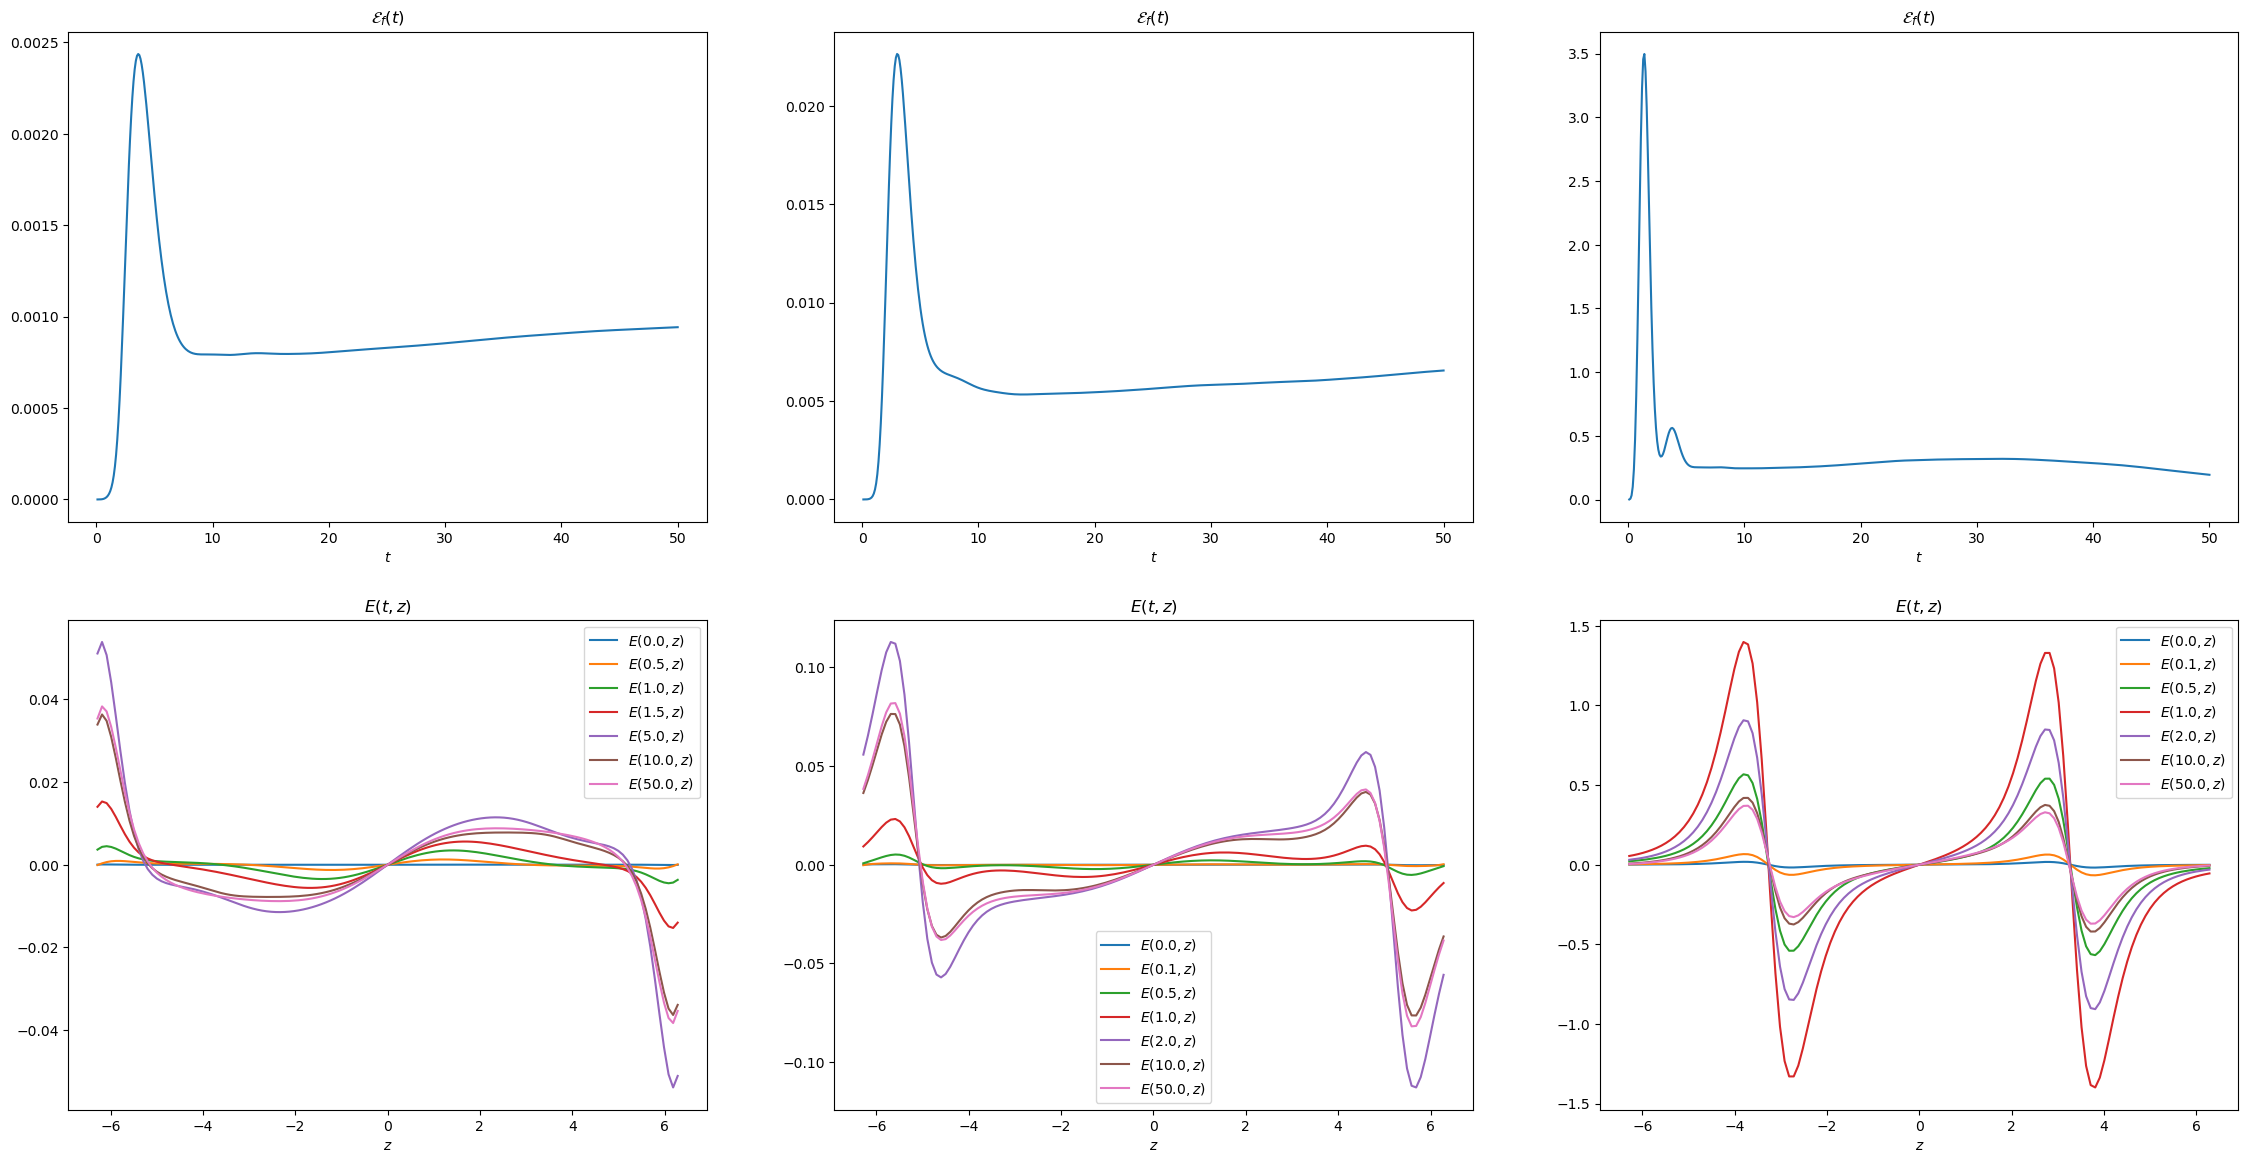

In [28]:
fig, axs = plt.subplots(2,3 ,figsize=(28, 14))

axs[0,0].plot(t_values[1:], ee_array_0)
axs[0,0].set_title("$\\mathcal{E}_{f}(t)$")
#axs[0,0].set_yscale('log')
axs[0,0].set_xlabel("$t$")

axs[1,0].plot(mesh.zs, E_array_0[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,0].plot(mesh.zs, E_array_0[5,:], label='$E({:.1f},z)$'.format(t_values[5]))
axs[1,0].plot(mesh.zs, E_array_0[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,0].plot(mesh.zs, E_array_0[15,:], label='$E({:.1f},z)$'.format(t_values[15]))
axs[1,0].plot(mesh.zs, E_array_0[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
axs[1,0].plot(mesh.zs, E_array_0[100,:], label='$E({:.1f},z)$'.format(t_values[100]))
axs[1,0].plot(mesh.zs, E_array_0[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,0].set_yscale('symlog')
axs[1,0].set_title("$E(t,z)$")
axs[1,0].set_xlabel("$z$")
axs[1,0].legend()


axs[0,1].plot(t_values[1:], ee_array_1)
axs[0,1].set_title("$\\mathcal{E}_{f}(t)$")
#axs[0,1].set_yscale('log')
axs[0,1].set_xlabel("$t$")

axs[1,1].plot(mesh.zs, E_array_1[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,1].plot(mesh.zs, E_array_1[1,:], label='$E({:.1f},z)$'.format(t_values[1]))
axs[1,1].plot(mesh.zs, E_array_1[5,:], label='$E({:.1f},z)$'.format(t_values[5]))
axs[1,1].plot(mesh.zs, E_array_1[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,1].plot(mesh.zs, E_array_1[20,:], label='$E({:.1f},z)$'.format(t_values[20]))
axs[1,1].plot(mesh.zs, E_array_1[100,:], label='$E({:.1f},z)$'.format(t_values[100]))
axs[1,1].plot(mesh.zs, E_array_1[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,1].set_yscale('symlog')
axs[1,1].set_title("$E(t,z)$")
axs[1,1].set_xlabel("$z$")
axs[1,1].legend()




axs[0,2].plot(t_values[1:], ee_array_2)
axs[0,2].set_title("$\\mathcal{E}_{f}(t)$")
#axs[0,2].set_yscale('log')
axs[0,2].set_xlabel("$t$")

axs[1,2].plot(mesh.zs, E_array_2[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,2].plot(mesh.zs, E_array_2[1,:], label='$E({:.1f},z)$'.format(t_values[1]))
axs[1,2].plot(mesh.zs, E_array_2[5,:], label='$E({:.1f},z)$'.format(t_values[5]))
axs[1,2].plot(mesh.zs, E_array_2[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,2].plot(mesh.zs, E_array_2[20,:], label='$E({:.1f},z)$'.format(t_values[20]))
axs[1,2].plot(mesh.zs, E_array_2[100,:], label='$E({:.1f},z)$'.format(t_values[100]))
axs[1,2].plot(mesh.zs, E_array_2[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,2].set_yscale('symlog')
axs[1,2].set_title("$E(t,z)$")
axs[1,2].set_xlabel("$z$")
axs[1,2].legend()



plt.show()
#plt.savefig('Mirror/Plots/two_coils/electric_energies.png', dpi=300, transparent=True, bbox_inches="tight")

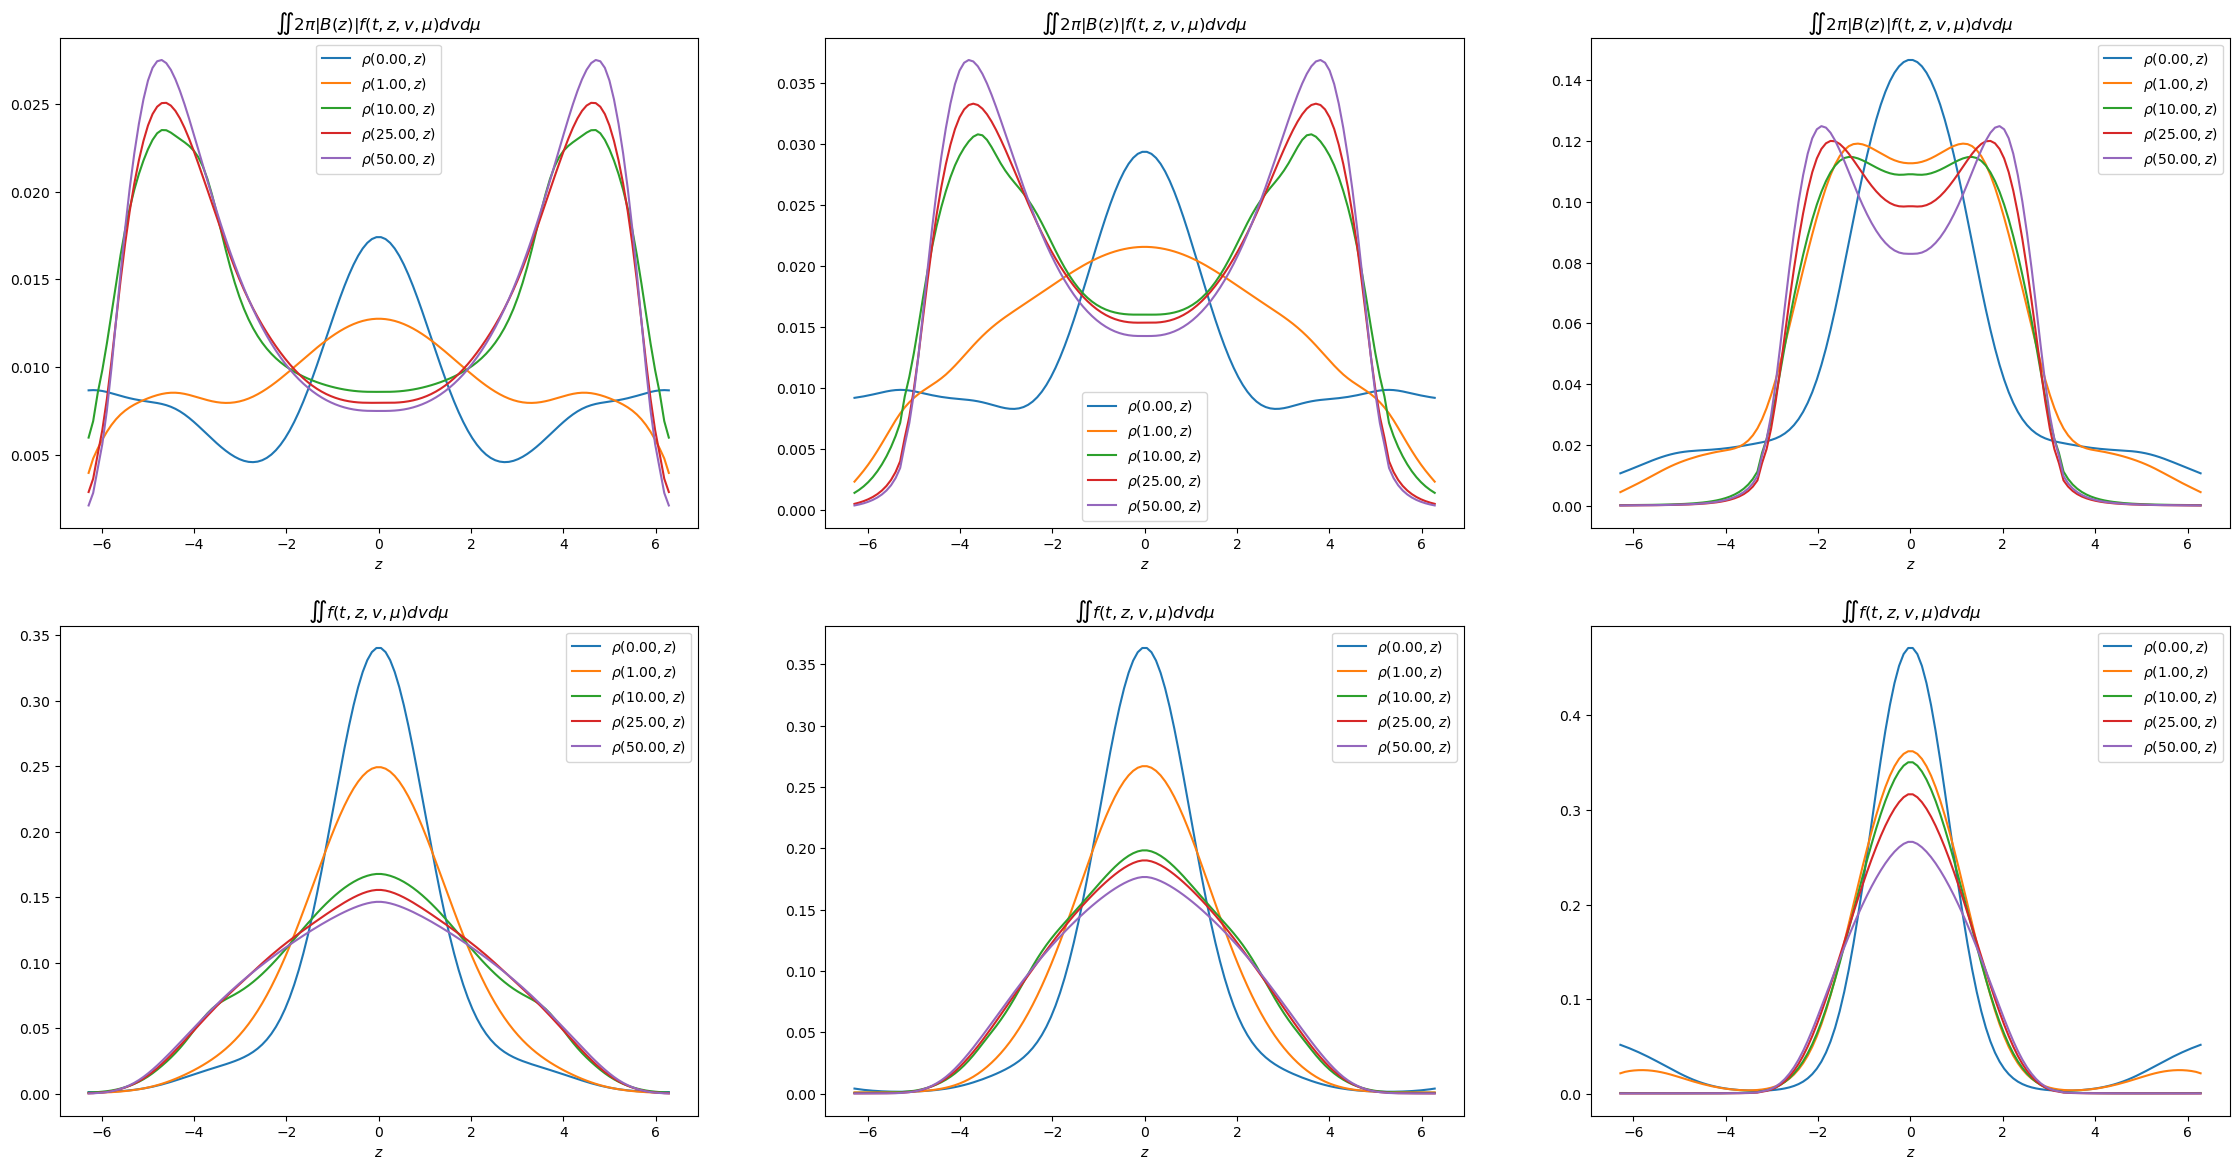

In [34]:
fig, axs = plt.subplots(2,3 ,figsize=(28, 14))

axs[0,0].plot(mesh.zs, 2*jnp.pi*B0*rho_array_0[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[0,0].plot(mesh.zs, 2*jnp.pi*B0*rho_array_0[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[0,0].plot(mesh.zs, 2*jnp.pi*B0*rho_array_0[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[0,0].plot(mesh.zs, 2*jnp.pi*B0*rho_array_0[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[0,0].plot(mesh.zs, 2*jnp.pi*B0*rho_array_0[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[0,0].set_title("$\\iint 2 \\pi |B(z)|f(t,z,v,\\mu)dvd\\mu$")
axs[0,0].set_xlabel("$z$")
#axs[0,0].set_yscale('log')
axs[0,0].legend()

axs[1,0].plot(mesh.zs, rho_array_0[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[1,0].plot(mesh.zs, rho_array_0[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[1,0].plot(mesh.zs, rho_array_0[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[1,0].plot(mesh.zs, rho_array_0[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[1,0].plot(mesh.zs, rho_array_0[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[1,0].set_title("$\\iint f(t,z,v,\\mu)dvd\\mu$")
axs[1,0].set_xlabel("$z$")
#axs[1,0].set_yscale('log')
axs[1,0].legend()


axs[0,1].plot(mesh.zs, 2*jnp.pi*B1*rho_array_1[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[0,1].plot(mesh.zs, 2*jnp.pi*B1*rho_array_1[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[0,1].plot(mesh.zs, 2*jnp.pi*B1*rho_array_1[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[0,1].plot(mesh.zs, 2*jnp.pi*B1*rho_array_1[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[0,1].plot(mesh.zs, 2*jnp.pi*B1*rho_array_1[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[0,1].set_title("$\\iint 2 \\pi |B(z)|f(t,z,v,\\mu)dvd\\mu$")
axs[0,1].set_xlabel("$z$")
#axs[0,1].set_yscale('log')
axs[0,1].legend()

axs[1,1].plot(mesh.zs, rho_array_1[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[1,1].plot(mesh.zs, rho_array_1[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[1,1].plot(mesh.zs, rho_array_1[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[1,1].plot(mesh.zs, rho_array_1[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[1,1].plot(mesh.zs, rho_array_1[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[1,1].set_title("$\\iint f(t,z,v,\\mu)dvd\\mu$")
axs[1,1].set_xlabel("$z$")
#axs[1,1].set_yscale('log')
axs[1,1].legend()


axs[0,2].plot(mesh.zs, 2*jnp.pi*B2*rho_array_2[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[0,2].plot(mesh.zs, 2*jnp.pi*B2*rho_array_2[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[0,2].plot(mesh.zs, 2*jnp.pi*B2*rho_array_2[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[0,2].plot(mesh.zs, 2*jnp.pi*B2*rho_array_2[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[0,2].plot(mesh.zs, 2*jnp.pi*B2*rho_array_2[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[0,2].set_title("$\\iint 2 \\pi |B(z)|f(t,z,v,\\mu)dvd\\mu$")
axs[0,2].set_xlabel("$z$")
#axs[0,2].set_yscale('log')
axs[0,2].legend()

axs[1,2].plot(mesh.zs, rho_array_2[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[1,2].plot(mesh.zs, rho_array_2[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[1,2].plot(mesh.zs, rho_array_2[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[1,2].plot(mesh.zs, rho_array_2[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[1,2].plot(mesh.zs, rho_array_2[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[1,2].set_title("$\\iint f(t,z,v,\\mu)dvd\\mu$")
axs[1,2].set_xlabel("$z$")
#axs[1,2].set_yscale('log')
axs[1,2].legend()



plt.show()
#plt.savefig('Mirror/Plots/two_coils/rho.png', dpi=300, transparent=True, bbox_inches="tight")

Now we want

$$\max \, \int \rho^{1D}(T,z) \mathrm{d}z + \lambda |\zeta|^{2}$$

Where
$$|B(z)| = \sum_{j=1}^{N} \frac{I_{j}R_{j}^{2}}{((z - \zeta_j)^{2} + R_{j}^{2})^{3/2}}.$$

For this, we fix $N$, $\{R_{j}\}_{j=1}^{N}$ and $\{I_{j}\}_{j=1}^{N}$. And we have $\{\zeta_j\}_{j=1}^{N}$ as variables. We pick $N=2$.

In [35]:
lam = 0.0

def cost_rho(rho_final, mesh):
    return jnp.sum(rho_final) * mesh.dz

vcost_rho = jax.vmap(cost_rho, in_axes=(0,None), out_axes=0)
cost_rho_grad = jax.grad(vcost_rho)
#vcost_rho_grad = jax.vmap(cost_rho_grad, in_axes=(0,None), out_axes=0)

#@jax.jit
def cost_fn(zeta):

    z_c1 = -LZ + zeta[0]
    z_c2 = LZ - zeta[1]
    z_c3 = 0.0
    
    B_norm_1 = build_B(I1, R1, z_c1)
    partial_B1_norm = build_partial_B(I1, R1, z_c1)
    B_norm_2 = build_B(I2, R2, z_c2)
    partial_B2_norm = build_partial_B(I2, R2, z_c2)

    B_norm = B_norm_1(mesh.Z) + B_norm_2(mesh.Z)

    bound_l = jnp.argwhere(B_norm_1(mesh.zs) == jnp.max(B_norm_1(mesh.zs)), size=1)[0,0]
    bound_u = jnp.argwhere(B_norm_2(mesh.zs) == jnp.max(B_norm_2(mesh.zs)), size=1)[0,0]
    
    f_eq = B_norm*jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) 
    f_iv = (0.1 + jnp.exp(-mesh.Z**2/(2*sigma_z**2))) * f_eq
    C = 1 / (jnp.sum((jnp.sum(f_iv, axis=(1,2))*mesh.dv*mesh.dmu)[bound_l:bound_u+1])*mesh.dz)
    f_iv = C * f_iv

    B = B_norm_1(mesh.zs) + B_norm_2(mesh.zs)
    partial_B = partial_B1_norm(mesh.zs) + partial_B2_norm(mesh.zs)
    g = partial_B / B

    f_array_1, f_total, E_array_1, ee_array_1, rho_array_1 = solver_jit(f_iv, B, partial_B, g, t_final=t_final)

    cost = cost_rho(rho_array_1[-1,bound_l:bound_u+1], mesh)

    return cost + lam*jnp.square(jnp.linalg.norm(zeta))

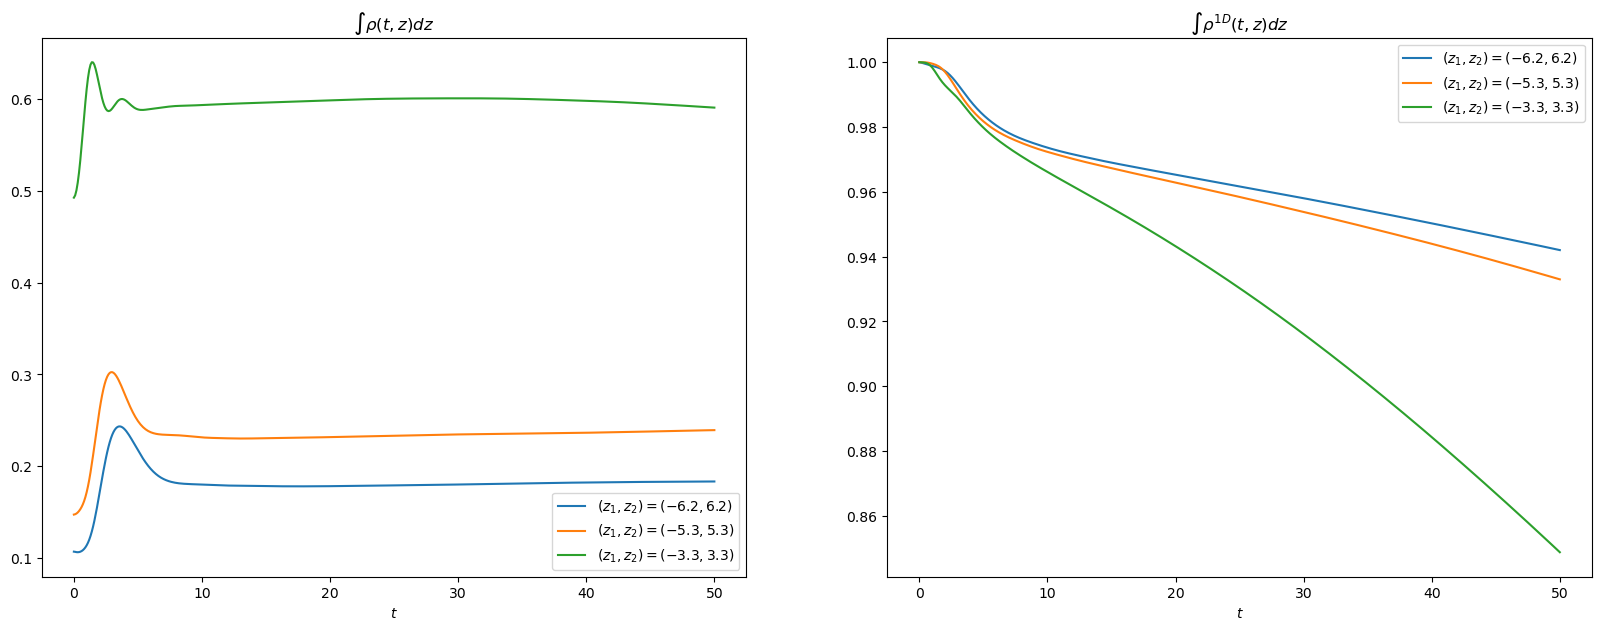

In [37]:
fig, axs = plt.subplots(1,2 ,figsize=(20, 7))

axs[0].plot(t_values, vcost_rho((2*jnp.pi*B0*rho_array_0)[:,bound_l0:bound_u0+1], mesh), label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[0],z_c2[0]))
axs[0].plot(t_values, vcost_rho((2*jnp.pi*B1*rho_array_1)[:,bound_l1:bound_u1+1], mesh), label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[1],z_c2[1]))
axs[0].plot(t_values, vcost_rho((2*jnp.pi*B2*rho_array_2)[:,bound_l2:bound_u2+1], mesh), label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[2],z_c2[2]))
axs[0].set_xlabel('$t$')
axs[0].set_title("$\\int \\rho(t,z)dz$")
axs[0].legend()


axs[1].plot(t_values, vcost_rho(rho_array_0[:,bound_l0:bound_u0+1], mesh), label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[0],z_c2[0]))
axs[1].plot(t_values, vcost_rho(rho_array_1[:,bound_l1:bound_u1+1], mesh), label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[1],z_c2[1]))
axs[1].plot(t_values, vcost_rho(rho_array_2[:,bound_l2:bound_u2+1], mesh), label='$(z_1,z_2)=({:.1f},{:.1f})$'.format(z_c1[2],z_c2[2]))
axs[1].set_xlabel('$t$')
axs[1].set_title("$\\int \\rho^{1D}(t,z)dz$")
#axs[1].set_yscale('log')
axs[1].legend()


#plt.show()
plt.savefig('Mirror/Plots/two_coils/int_rho.png', dpi=300, transparent=True, bbox_inches="tight")

In [15]:
zetas = jnp.linspace(0.1, 3.0, 50)
z_c1 = 
#print(zetas)

In [ ]:
costs = np.zeros((50,50))

for i in range(50):
    for j in range(50):
        costs[i,j] = cost_fn(jnp.array([zetas[i], zetas[j]]))

In [ ]:
jnp.savez('Mirror/Costs/cost_00_3B_E.npz', cost=costs, zeta=zetas)

In [ ]:
lam = 0.1

def cost_rho(rho_final, mesh):
    return jnp.sum(rho_final) * mesh.dz

vcost_rho = jax.vmap(cost_rho, in_axes=0, out_axes=0)

#@jax.jit
def cost_fn(zeta):

    z_c1 = -LZ + zeta[0]
    z_c2 = LZ - zeta[1]
    
    B_norm_1 = build_B(I1, R1, z_c1)
    partial_B1_norm = build_partial_B(I1, R1, z_c1)
    B_norm_2 = build_B(I2, R2, z_c2)
    partial_B2_norm = build_partial_B(I2, R2, z_c2)

    B_norm = B_norm_1(mesh.Z) + B_norm_2(mesh.Z)

    bound_l = jnp.argwhere(B_norm_1(mesh.zs) == jnp.max(B_norm_1(mesh.zs)), size=1)[0,0]
    bound_u = jnp.argwhere(B_norm_2(mesh.zs) == jnp.max(B_norm_2(mesh.zs)), size=1)[0,0]

    
    f_eq = B_norm*jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) 
    f_iv = (0.1 + jnp.exp(-mesh.Z**2/(2*sigma_z**2))) * f_eq
    C = 1 / (jnp.sum((jnp.sum(f_iv, axis=(1,2))*mesh.dv*mesh.dmu)[bound_l:bound_u+1])*mesh.dz)
    f_iv = C * f_iv

    B = B_norm_1(mesh.zs) + B_norm_2(mesh.zs)
    partial_B = partial_B1_norm(mesh.zs) + partial_B2_norm(mesh.zs)
    g = partial_B / B

    f_array_1, f_total, E_array_1, ee_array_1, rho_array_1 = solver_jit(f_iv, B, partial_B, g, t_final=t_final)

    cost = cost_rho(rho_array_1[-1,bound_l:bound_u+1], mesh)

    return cost - lam*jnp.square(jnp.linalg.norm(zeta))

In [ ]:
costs = np.zeros((50,50))

for i in range(50):
    for j in range(50):
        costs[i,j] = cost_fn(jnp.array([zetas[i], zetas[j]]))

jnp.savez('Mirror/Costs/cost_01_3B_E.npz', cost=costs, zeta=zetas)

In [21]:
file = jnp.load('Mirror/Costs/cost_00_B_E.npz')
costs_00 = file['cost']
zetas = file['zeta']

file = jnp.load('Mirror/Costs/cost_00_3B_E.npz')
costs_01 = file['cost']

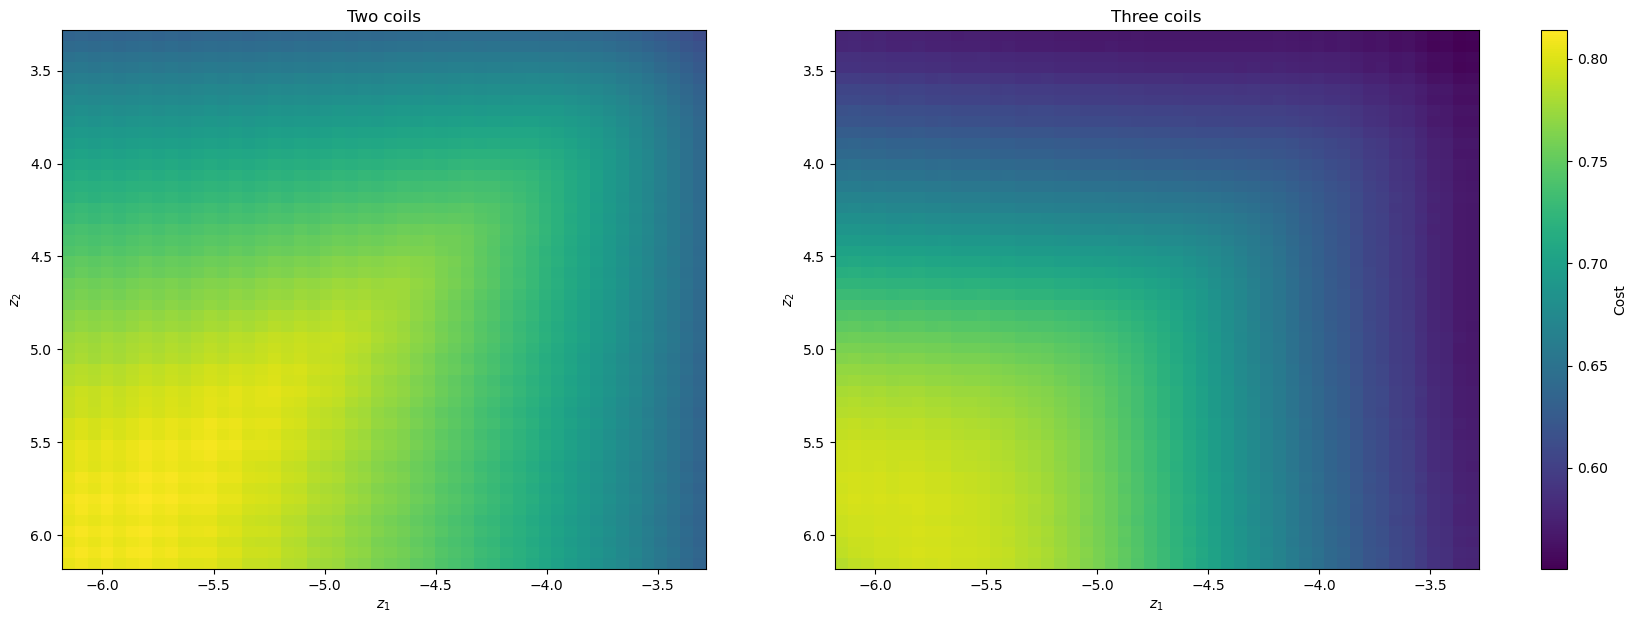

In [23]:
fig, axs = plt.subplots(1,2 ,figsize=(20, 7))

# Shared color scale
vmin = min(costs_00.min(), costs_01.min())
vmax = max(costs_00.max(), costs_01.max())

im0 = axs[0].imshow(
    costs_00,
    origin='lower',
    extent=[-LZ + zetas[0], -LZ + zetas[-1], LZ - zetas[0], LZ - zetas[-1]],
    aspect='auto',
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel(r'$z_{1}$')
axs[0].set_ylabel(r'$z_{2}$')
axs[0].set_title('Two coils')

im1 = axs[1].imshow(
    costs_01,
    origin='lower',
    extent=[-LZ + zetas[0], -LZ + zetas[-1], LZ - zetas[0], LZ - zetas[-1]],
    aspect='auto',
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel(r'$z_{1}$')
axs[1].set_ylabel(r'$z_{2}$')
axs[1].set_title('Three coils')

# Single shared colorbar
cbar = fig.colorbar(im0, ax=axs, fraction=0.046, pad=0.04)
cbar.set_label('Cost')

plt.show()